# 03 — Decision-Threshold Optimization

**Objective:** Stage 4 deliberately did not pick a winning model or an operating threshold on PR-AUC/ROC-AUC alone. Here we sweep the probability threshold for both finalist models (Random Forest, XGBoost) across precision, recall, F1, FPR, and alert volume, then pick a threshold against a stated business constraint rather than defaulting to 0.5.

Evaluated on the **validation split**; `fraudTest.csv` stays untouched until final confirmation.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

import preprocessing as pp
import train as tr
import evaluate as ev

sns.set_style('whitegrid')
DATA_DIR = '../data'
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

## Load data, split, and train the two finalist models

Same Stage 2 split and Stage 4b setup (class weighting on both, same random state) — reproduced here rather than re-run in a notebook we'd have to keep open, and saved to `models/` so later stages (investigator queue, error analysis, explainability, dashboard) can load instead of retraining.

In [2]:
train_raw = pp.engineer_features(pp.load_raw(f'{DATA_DIR}/fraudTrain.csv'))
test_raw = pp.engineer_features(pp.load_raw(f'{DATA_DIR}/fraudTest.csv'))
train_split, val_split = pp.temporal_train_val_split(train_raw, val_weeks=6)

X_train, y_train = pp.split_X_y(train_split)
X_val, y_val = pp.split_X_y(val_split)

preprocessor = pp.build_preprocessor()
Xt_train = preprocessor.fit_transform(X_train)
Xt_val = preprocessor.transform(X_val)

spw = tr.class_weight_ratio(y_train)
models = tr.build_models(class_weighted=True, scale_pos_weight=spw)
finalists = {name: models[name] for name in ['Random Forest', 'XGBoost']}

probas = {}
for name, model in finalists.items():
    model.fit(Xt_train, y_train)
    probas[name] = model.predict_proba(Xt_val)[:, 1]
    print(f'{name} trained.')

joblib.dump(preprocessor, MODELS_DIR / 'preprocessor.pkl')
joblib.dump(finalists['Random Forest'], MODELS_DIR / 'random_forest.pkl')
joblib.dump(finalists['XGBoost'], MODELS_DIR / 'xgboost.pkl')
print('Saved preprocessor + both models to', MODELS_DIR.resolve())

Random Forest trained.


XGBoost trained.
Saved preprocessor + both models to /Users/alihussein/Desktop/FraudDetection/models


## Sweep thresholds

In [3]:
def threshold_sweep(y_true, y_proba, thresholds):
    y_true = np.asarray(y_true)
    n = len(y_true)
    rows = []
    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        m = ev.fraud_metrics(y_true, pred, y_proba)
        n_alerts = int(pred.sum())
        rows.append({
            'threshold': t,
            'precision': m['precision'],
            'recall': m['recall'],
            'f1': m['f1'],
            'fpr': m['fpr'],
            'n_alerts': n_alerts,
            'pct_flagged': 100 * n_alerts / n,
        })
    return pd.DataFrame(rows)

fine_grid = np.round(np.arange(0.01, 1.00, 0.01), 2)
sweep_results = {name: threshold_sweep(y_val, probas[name], fine_grid) for name in finalists}

display_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for name in finalists:
    print(f'--- {name} ---')
    print(sweep_results[name][sweep_results[name]['threshold'].isin(display_grid)]
          .set_index('threshold').round(4))
    print()

--- Random Forest ---
           precision  recall      f1     fpr  n_alerts  pct_flagged
threshold                                                          
0.1           0.4863  0.9283  0.6382  0.0059      1277       1.1445
0.2           0.6822  0.8954  0.7744  0.0025       878       0.7869
0.3           0.7803  0.8759  0.8254  0.0015       751       0.6731
0.4           0.8604  0.8565  0.8584  0.0008       666       0.5969
0.5           0.9076  0.8371  0.8709  0.0005       617       0.5530
0.6           0.9436  0.7997  0.8657  0.0003       567       0.5082
0.7           0.9751  0.7608  0.8547  0.0001       522       0.4678
0.8           0.9874  0.7010  0.8199  0.0001       475       0.4257
0.9           0.9949  0.5859  0.7375  0.0000       394       0.3531

--- XGBoost ---
           precision  recall      f1     fpr  n_alerts  pct_flagged
threshold                                                          
0.1           0.2005  0.9895  0.3335  0.0238      3301       2.9584
0.2      

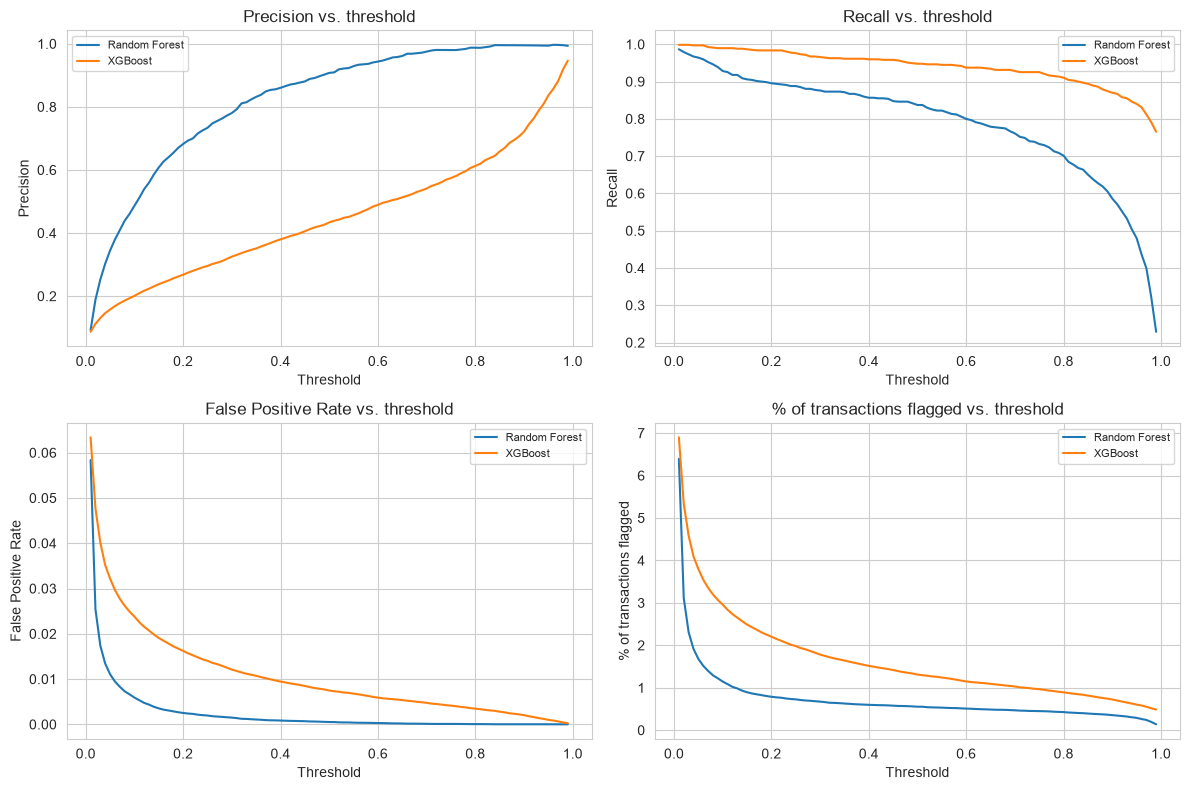

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metric_specs = [('precision', 'Precision'), ('recall', 'Recall'), ('fpr', 'False Positive Rate'), ('pct_flagged', '% of transactions flagged')]

for ax, (col, title) in zip(axes.flat, metric_specs):
    for name, df in sweep_results.items():
        ax.plot(df['threshold'], df[col], label=name)
    ax.set_xlabel('Threshold')
    ax.set_ylabel(title)
    ax.set_title(f'{title} vs. threshold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Choosing an operating point

**Business constraint (Option A):** maximize fraud recall subject to `False Positive Rate <= 0.5%`. This caps how often a legitimate customer gets wrongly flagged at roughly 1-in-200 — a defensible ceiling for customer friction — while asking the model to catch as much real fraud as it can within that budget. (Stage 6 separately explores the alternative framing of capping investigator review *volume* rather than FPR.)

In [5]:
FPR_CAP = 0.005

def best_threshold_under_fpr_cap(sweep_df, fpr_cap):
    feasible = sweep_df[sweep_df['fpr'] <= fpr_cap]
    if feasible.empty:
        return None
    return feasible.loc[feasible['recall'].idxmax()]

chosen = {}
for name, df in sweep_results.items():
    row = best_threshold_under_fpr_cap(df, FPR_CAP)
    chosen[name] = row
    print(f'--- {name}: best threshold under FPR <= {FPR_CAP*100:.1f}% ---')
    print(row)
    print()

--- Random Forest: best threshold under FPR <= 0.5% ---
threshold         0.120000
precision         0.539069
recall            0.917788
f1                0.679204
fpr               0.004733
n_alerts       1139.000000
pct_flagged       1.020783
Name: 11, dtype: float64

--- XGBoost: best threshold under FPR <= 0.5% ---
threshold         0.680000
precision         0.530213
recall            0.931241
f1                0.675705
fpr               0.004977
n_alerts       1175.000000
pct_flagged       1.053047
Name: 67, dtype: float64



### Selected operating point

Under the constraint **FPR <= 0.5%**, both finalists land in almost the same place, just at very different thresholds:

| Model | Threshold | Precision | Recall | F1 | FPR | Alerts (% flagged) |
|---|---|---|---|---|---|---|
| Random Forest | 0.12 | 0.539 | 0.918 | 0.679 | 0.0047 | 1,139 (1.02%) |
| XGBoost | 0.68 | 0.530 | 0.931 | 0.676 | 0.0050 | 1,175 (1.05%) |

At this operating point the two models are close enough to call a tie: XGBoost catches slightly more fraud (93.1% vs. 91.8% recall) at essentially the same false-positive rate, while Random Forest is very slightly cleaner on precision. In plain terms: **at a threshold tuned to flag about 1% of all transactions, either model catches roughly 92-93% of real fraud, and about half of every alert raised is a true fraud case.**

**Recommendation:** carry Random Forest forward as the primary model for Stages 6-11. Its threshold (0.12) sits in a less sensitive part of the curve than XGBoost's (0.68, near the top of XGBoost's probability range, where small drift in score calibration would swing the alert volume more) - see the earlier threshold-sweep plots - and it's also faster to explain to a non-technical investigator ('flag anything the model scores as more than 12% likely to be fraud') and to explain via SHAP in Stage 8. XGBoost remains a documented, nearly-tied alternative, not a discarded option - this is a close call, not a decisive win.

Note this is one defensible choice (Option A: maximize recall subject to an FPR cap), not the only one - Stage 6's investigator-capacity framing (capping *review volume* directly rather than FPR) gives a complementary view on the same tradeoff.